Congrats! You just graduated UVA's BSDS program and got a job working at a movie studio in Hollywood. 

Your boss is the head of the studio and wants to know if they can gain a competitive advantage by predicting new movies that might get high imdb scores (movie rating). 

You would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so, similar to  great data scientists of the past you remembered the excellent education provided to you at UVA in a undergrad data science course and have outline 20ish steps that will need to be undertaken to complete this task. As always, you will need to make sure to #comment your work heavily. 

 Footnotes: 
-	You can add or combine steps if needed
-	Also, remember to try several methods during evaluation and always be mindful of how the model will be used in practice.
- Make sure all your variables are the correct type (factor, character,numeric, etc.)

## Import the libraries and the dataset

In [342]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import graphviz 

from sklearn.model_selection import train_test_split,GridSearchCV,RepeatedStratifiedKFold
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, export_graphviz

In [343]:
#1. Load the data
#Sometimes need to set the working directory back out of a folder that we create a file in

#import os
#os.listdir()
#print(os.getcwd())
#os.chdir('c:\\Users\\Brian Wright\\Documents\\3001Python\\DS-3001')

movie_metadata=pd.read_csv("../data/movie_metadata.csv")

## Check for missing variables and correct as needed.

In [344]:
#calculate the number of missing values in each column
movie_metadata.isna().sum()
#drop rows with missing data
movie_metadata=movie_metadata.dropna()

In [345]:
movie_metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3755 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      3755 non-null   object 
 1   director_name              3755 non-null   object 
 2   num_critic_for_reviews     3755 non-null   float64
 3   duration                   3755 non-null   float64
 4   director_facebook_likes    3755 non-null   float64
 5   actor_3_facebook_likes     3755 non-null   float64
 6   actor_2_name               3755 non-null   object 
 7   actor_1_facebook_likes     3755 non-null   float64
 8   gross                      3755 non-null   float64
 9   genres                     3755 non-null   object 
 10  actor_1_name               3755 non-null   object 
 11  movie_title                3755 non-null   object 
 12  num_voted_users            3755 non-null   int64  
 13  cast_total_facebook_likes  3755 non-null   int64  
 1

In [346]:
#drop irrelevant columns
movie_metadata=movie_metadata.drop(['movie_title','plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'],axis=1)

In [347]:
#convert the object variables into categorical variables
categorical=movie_metadata.select_dtypes(include=[object]).columns.tolist()
movie_metadata[categorical]=movie_metadata[categorical].astype('category')

## 3 Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.

In [348]:
#use one hot encoding for other categorical variables
encoder = OneHotEncoder(sparse_output=False)

In [349]:
#movie_metadata['imdb_score']=movie_metadata['imdb_score'].astype('float64')

In [350]:
# Categorize imdb_score into two classes
movie_metadata["imdb_score"] = movie_metadata["imdb_score"].apply(
    lambda x: "high" if x >= 7.5 else "average" if x >= 5.0 else "low"
)

# Check the value counts
#print(movie_metadata["imdb_score"].value_counts())

imdb_encoded=encoder.fit_transform(movie_metadata[["imdb_score"]])
imdb_1h = pd.DataFrame(
    imdb_encoded,
    columns=encoder.get_feature_names_out(['imdb_score']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['imdb_score']), imdb_1h], axis=1)

In [351]:
## encode directors
dir_val=movie_metadata['director_name'].value_counts().nlargest(10).index

#print(dir_val)

movie_metadata['director_name']=movie_metadata['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')

#print(movie_metadata['director_name'].value_counts())

#one hot encode
dir_encoded = encoder.fit_transform(movie_metadata[["director_name"]])
dir_1h = pd.DataFrame(
    dir_encoded,
    columns=encoder.get_feature_names_out(['director_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['director_name']), dir_1h], axis=1)

#print(movie_metadata["director_name"].value_counts())

In [352]:
## encode title_year
movie_metadata["title_year"] = movie_metadata["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)

title_encoded=encoder.fit_transform(movie_metadata[["title_year"]])
title_1h = pd.DataFrame(
    title_encoded,
    columns=encoder.get_feature_names_out(['title_year']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['title_year']), title_1h], axis=1)

In [353]:
## encode first actor
act_10 = list(movie_metadata['actor_1_name'].value_counts().nlargest(10).index)

#print(act_10)

# Create a new column so you can compare after
movie_metadata['actor_1_name'] = movie_metadata['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)

#print(movie_metadata['actor_1_name'].value_counts())

act_encoded = encoder.fit_transform(movie_metadata[["actor_1_name"]])
act_1h = pd.DataFrame(
    act_encoded,
    columns=encoder.get_feature_names_out(['actor_1_name']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['actor_1_name']), act_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [354]:
## encode country
count10=movie_metadata['country'].value_counts().nlargest(10)
#print(count10)

movie_metadata['country']=movie_metadata['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata['country'].value_counts())

count_encoded = encoder.fit_transform(movie_metadata[["country"]])
count_1h = pd.DataFrame(
    count_encoded,
    columns=encoder.get_feature_names_out(['country']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['country']), count_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [355]:
## encode content rating
#print(movie_metadata['content_rating'].value_counts())
movie_metadata['content_rating']=movie_metadata['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')

#print(movie_metadata['content_rating'].value_counts())

cont_encoded = encoder.fit_transform(movie_metadata[["content_rating"]])
cont_1h = pd.DataFrame(
    cont_encoded,
    columns=encoder.get_feature_names_out(['content_rating']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['content_rating']), cont_1h], axis=1)
#print(movie_metadata['actor_1_name'])

In [356]:
## encode language
lang10=movie_metadata['language'].value_counts().nlargest(10)
#print(lang10)

movie_metadata['language']=movie_metadata['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata['language'].value_counts())

#movie_metadata[['language']]=OneHotEncoder().fit_transform(movie_metadata[['language']])
#print(movie_metadata['language'].value_counts())

language_encoded = encoder.fit_transform(movie_metadata[['language']])

language_1h = pd.DataFrame(
    language_encoded,
    columns=encoder.get_feature_names_out(['language']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['language']), language_1h], axis=1)

In [357]:
## encode color
#print(movie_metadata['color'].value_counts())
movie_metadata['color']=movie_metadata['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')
#movie_metadata[['color']]=OneHotEncoder().fit_transform(movie_metadata[['color']])
#print(movie_metadata['color'].value_counts())

color_encoded = encoder.fit_transform(movie_metadata[['color']])

color_1h = pd.DataFrame(
    color_encoded,
    columns=encoder.get_feature_names_out(['color']),
    index=movie_metadata.index
)

movie_metadata = pd.concat([movie_metadata.drop(columns=['color']), color_1h], axis=1)

In [358]:
movie_metadata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3755 entries, 0 to 5042
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num_critic_for_reviews        3755 non-null   float64
 1   duration                      3755 non-null   float64
 2   director_facebook_likes       3755 non-null   float64
 3   actor_3_facebook_likes        3755 non-null   float64
 4   actor_1_facebook_likes        3755 non-null   float64
 5   gross                         3755 non-null   float64
 6   num_voted_users               3755 non-null   int64  
 7   cast_total_facebook_likes     3755 non-null   int64  
 8   facenumber_in_poster          3755 non-null   float64
 9   num_user_for_reviews          3755 non-null   float64
 10  budget                        3755 non-null   float64
 11  actor_2_facebook_likes        3755 non-null   float64
 12  aspect_ratio                  3755 non-null   float64
 13  movie_fa

## 4 Guess what, you don't need to scale the data, because DTs don't require this to be done, they make local greedy decisions...keeps getting easier, go to the next step.

## 5 Determine the baserate or prevalence for the classifier, what does this number mean?

In [359]:
#calculate the prevalence
print(movie_metadata['imdb_score_high'].value_counts()) #633/3122
print(633/3122)

imdb_score_high
0.0    3122
1.0     633
Name: count, dtype: int64
0.20275464445868033


This number means that the possibility of predicting a movie with a high imdb score is 0.203.

## 6 Split your data into test, tune, and train. (80/10/10)

In [360]:
X= movie_metadata.drop(columns=['imdb_score_high','imdb_score_average'])
y= movie_metadata['imdb_score_high']

In [361]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.70, stratify= y, random_state=21)
X_tune, X_test, y_tune, y_test = train_test_split(X_test,y_test,  train_size = 0.50,stratify= y_test, random_state=49)

## 7 Create the kfold object for cross validation.

In [362]:
from sklearn.model_selection import RepeatedStratifiedKFold

kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)

## 8 Create the scoring metric you will use to evaluate your model and the max depth hyperparameter 

In [363]:
scoring = ['roc_auc','recall','balanced_accuracy']
param={"max_depth" : [1,2,3,4,5,6,7,8,9,10,11]}

## 9 Build the classifier object 

In [364]:
cl= DecisionTreeClassifier(random_state=1000)

## 10 Use the kfold object and the scoring metric to find the best hyperparameter value for max depth via the grid search method.

In [365]:
#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')

## 11 Fit the model to the training data.

In [366]:
#execute search on our training data, this may take a few seconds ...
model = search.fit(X_train, y_train)

## 12 What is the best depth value?

In [367]:
#Retrieve the best estimator out of all parameters passed, based on highest roc_auc
best = model.best_estimator_
print(best)
print(best.score(X_train, y_train))

DecisionTreeClassifier(max_depth=5, random_state=1000)
0.910958904109589


The best depth value is 5.

## 13 Print out the model

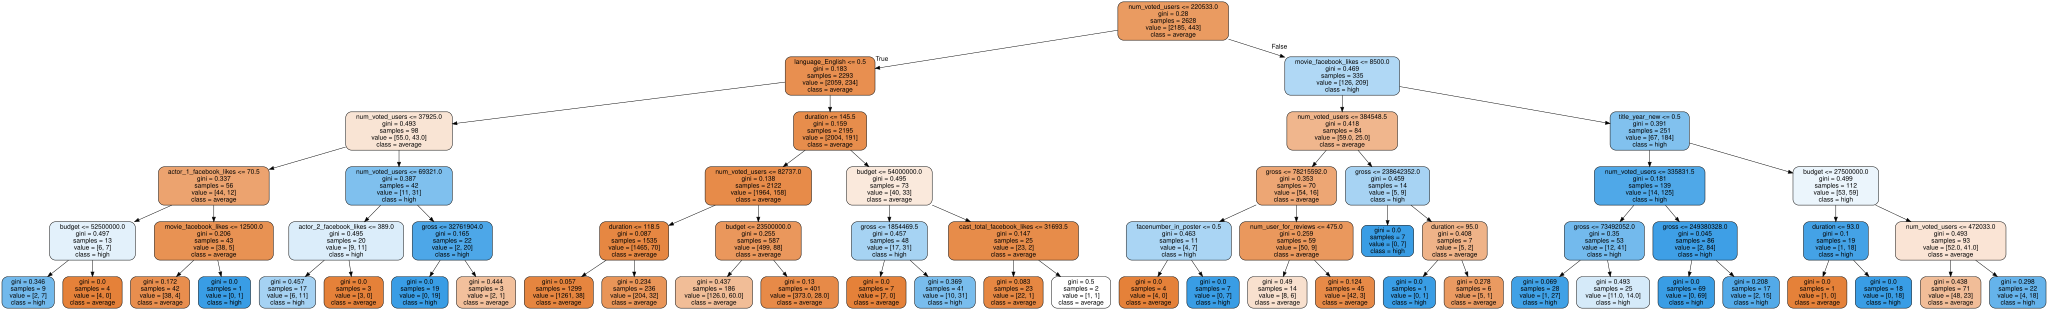

In [368]:
dot_data = export_graphviz(best, out_file =None,
               feature_names =X.columns, #feature names from dataset
               filled=True, 
                rounded=True, 
                class_names = ['average','high']) #classification labels 
               
graph=graphviz.Source(dot_data)
graph

## 14 View the results, comment on how the model performed using several evaluation metrics. (ROC, F1)

In [369]:
#What about the specific scores (roc_auc, recall, balanced_accuracy)? Let's try and extract them to see what we are working with ...
print(model.cv_results_) #This is a dictionary and in order to extract info we need the keys

{'mean_fit_time': array([0.00548761, 0.00717286, 0.00935481, 0.01081189, 0.01309872,
       0.01452559, 0.01880536, 0.02182471, 0.02985307, 0.02697994,
       0.02634115]), 'std_fit_time': array([0.01084444, 0.00308451, 0.00310425, 0.00314253, 0.00310795,
       0.00282934, 0.00516196, 0.00797767, 0.0134493 , 0.00832196,
       0.00601761]), 'mean_score_time': array([0.00491742, 0.00618253, 0.00587846, 0.00525558, 0.00550255,
       0.00405806, 0.00423579, 0.00519505, 0.00709528, 0.00712362,
       0.00529304]), 'std_score_time': array([0.00809409, 0.00403358, 0.00397014, 0.00287652, 0.00354311,
       0.00218157, 0.00241859, 0.00364866, 0.00438168, 0.00451569,
       0.0029071 ]), 'param_max_depth': masked_array(data=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False],
       fill_value=999999), 'params': [{'max_depth': 1}, {'max_depth': 2}, {'max_depth': 3}, {'max_depth': 4}, {'max_dep

In [370]:
#Let's extract these scores, using our function!

#Scores: 

auc = model.cv_results_['mean_test_roc_auc']
recall= model.cv_results_['mean_test_recall']
bal_acc= model.cv_results_['mean_test_balanced_accuracy']

SDauc = model.cv_results_['std_test_roc_auc']
SDrecall= model.cv_results_['std_test_recall']
SDbal_acc= model.cv_results_['std_test_balanced_accuracy']

#Parameter:
depth= np.unique(model.cv_results_['param_max_depth']).data

#Build DataFrame:
final_model = pd.DataFrame(list(zip(depth, auc, recall, bal_acc,SDauc,SDrecall,SDbal_acc)),
               columns =['depth','auc','recall','bal_acc','aucSD','recallSD','bal_accSD'])

#Let's take a look
final_model.style.hide(axis='index')

depth,auc,recall,bal_acc,aucSD,recallSD,bal_accSD
1,0.704552,0.466949,0.704552,0.034692,0.066617,0.034692
2,0.732855,0.338515,0.651867,0.032854,0.126904,0.056524
3,0.778721,0.405515,0.686697,0.033319,0.067956,0.031427
4,0.811272,0.438414,0.704972,0.031906,0.071548,0.036681
5,0.812421,0.454778,0.712563,0.033608,0.066546,0.034399
6,0.810669,0.470525,0.711372,0.034773,0.066952,0.032441
7,0.782366,0.483182,0.719256,0.041623,0.060954,0.031402
8,0.766247,0.511616,0.730221,0.044067,0.066673,0.034193
9,0.744304,0.523333,0.732234,0.044506,0.057102,0.032350
10,0.725968,0.531434,0.732257,0.048418,0.058448,0.030879


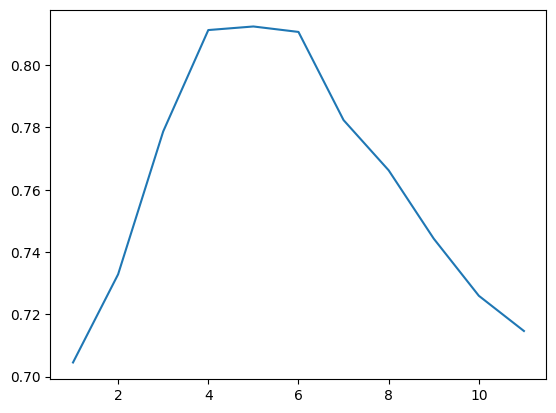

In [371]:
print(plt.plot(final_model.depth,final_model.auc))

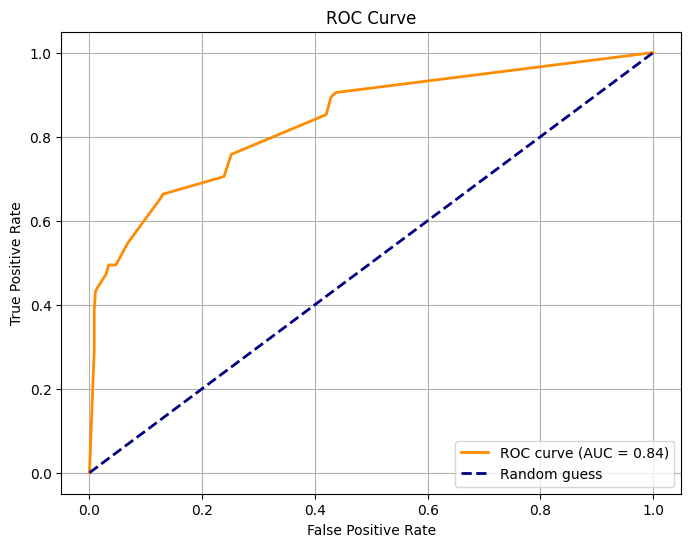

In [372]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class (high)
y_probs = model.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

## 15 Which variables appear to be contributing the most (variable importance) 

In [373]:
#Variable importance for the best estimator, how much weight does each feature have in determining the classification?
imp=pd.DataFrame(best.feature_importances_,index = X.columns,columns=['importance']).sort_values('importance', ascending=False)
print(imp)

                              importance
num_voted_users                 0.542622
budget                          0.104065
duration                        0.075520
movie_facebook_likes            0.069366
language_English                0.063233
gross                           0.059232
title_year_new                  0.046881
facenumber_in_poster            0.013866
actor_1_facebook_likes          0.009692
num_user_for_reviews            0.007619
actor_2_facebook_likes          0.005816
cast_total_facebook_likes       0.002089
content_rating_R                0.000000
content_rating_Other            0.000000
content_rating_PG-13            0.000000
num_critic_for_reviews          0.000000
language_French                 0.000000
country_Big Country Producer    0.000000
language_Other                  0.000000
color_Black and White           0.000000
country_Other                   0.000000
director_name_Other             0.000000
actor_1_name_Other              0.000000
actor_1_name_Fam

Number of users for reviews is the most important feature.

Axes(0.125,0.11;0.775x0.77)


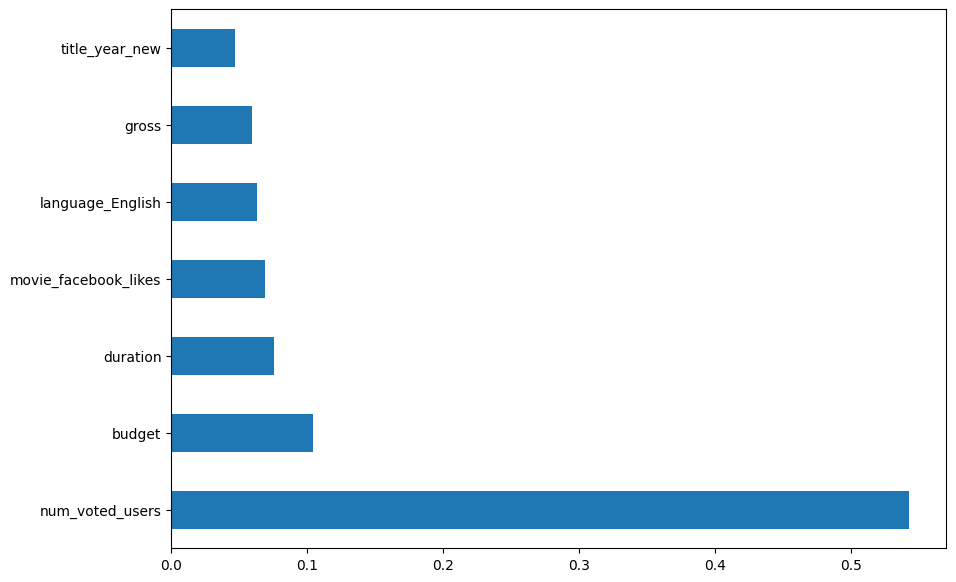

In [374]:
#Graph variable importance
plt.figure(figsize=(10,7))
print(imp.importance.nlargest(7).plot(kind='barh'))

## 16 Use the predict method on the test data and print out the results. 17 How does the model perform on the test data?

In [ ]:
scoring = ['roc_auc','recall','balanced_accuracy']
param={"max_depth" : [5]}
cl = DecisionTreeClassifier(random_state=1000)
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')
model = search.fit(X_train, y_train)
best = model.best_estimator_
print(best)
test_score = best.score(X_test,y_test)
print(test_score)

DecisionTreeClassifier(max_depth=5, random_state=1000)
0.8829787234042553


The model has an accuracy of 0.88. There is an improvement in the model performance compared with the accuracy of the training data, which is 0.86.

## 18 Print out the confusion matrix for the test data, what does it tell you about the model?

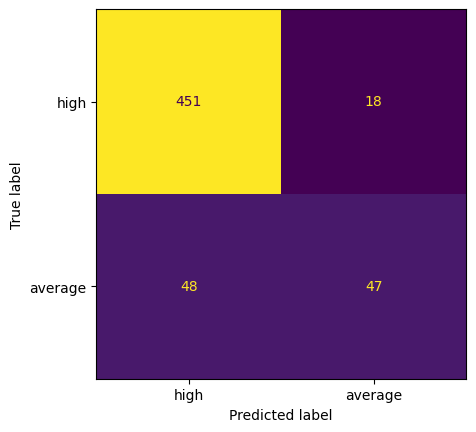

In [287]:
print(ConfusionMatrixDisplay.from_estimator(best,X_test,y_test, display_labels = ['high','average'], colorbar=False))

The true positive is 451/564 = 0.80 the true negative is 47/564 = 0.08, the false positive is 48/564 = 0.0851, and the false negative is 18/564 = 0.0319.

## 19 What are the top 3 movies based on the test set? Which variables are most important in predicting the top 3 movies?

In [378]:
# Predict probabilities
probs = model.predict_proba(X_test)

# Get probability of predicting a high imdb score
X_test_copy = X_test.copy()
X_test_copy['prob_high'] = probs[:, 1]

#re-access the movie_metadata data to acquire the movie titles
movie_title=pd.read_csv("../data/movie_metadata.csv")
X_test_copy=pd.concat([X_test_copy,movie_title['movie_title']],axis=1)

In [379]:
top_3 = X_test_copy.sort_values(by='prob_high', ascending=False).head(3)
print(top_3[['movie_title', 'prob_high']])

             movie_title  prob_high
1600              Se7en         1.0
400      Ocean's Eleven         1.0
1627  Midnight in Paris         1.0


number of users for review is the most important factor.

## *What if I drop all the categorical variables?

In [407]:
movie_metadata2=pd.read_csv("../data/movie_metadata.csv")
cat = movie_metadata2.select_dtypes(include=[object]).columns.tolist()
movie_metadata2=movie_metadata2.drop(cat,axis=1)
movie_metadata2 = movie_metadata2.dropna()
#create the target variable
movie_metadata2['imdb_score'] = movie_metadata2['imdb_score'].apply(
    lambda x: 'high' if x >= 7.5 else 'average'
)
encoder = OneHotEncoder(sparse_output=False)
imdb_encoded = encoder.fit_transform(movie_metadata2[['imdb_score']])
imdb_1h = pd.DataFrame(
    imdb_encoded,
    columns=encoder.get_feature_names_out(['imdb_score']),
    index=movie_metadata2.index
)
movie_metadata2 = pd.concat([movie_metadata2.drop(columns=['imdb_score']), imdb_1h], axis=1)
#train test split
X2 = movie_metadata2.drop(columns=['imdb_score_high','imdb_score_average'])
y2 = movie_metadata2['imdb_score_high']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, train_size=0.70, stratify=y2, random_state=21)
X2_tune, X2_test, y2_tune, y2_test = train_test_split(X2_test, y2_test, train_size=0.50, stratify=y2_test, random_state=49)
#create the kfold classifer
from sklearn.model_selection import RepeatedStratifiedKFold
kf = RepeatedStratifiedKFold(n_splits=10,n_repeats =5, random_state=42)
#create scoring metrics
scoring = ['roc_auc','recall','balanced_accuracy']
param={"max_depth" : [1,2,3,4,5,6,7,8,9,10,11]}
#create the decision tree classifier
cl= DecisionTreeClassifier(random_state=1000)
#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')
#execute search on our training data
model2 = search.fit(X2_train, y2_train)
#Retrieve the best estimator out of all parameters passed
best2 = model2.best_estimator_
print(best2)
print(best2.score(X2_test,y2_test))

DecisionTreeClassifier(max_depth=5, random_state=1000)
0.8704028021015762


I can still achieve a decent level of accuracy. In fact, it's only slightly lower than the accuracy of the model with all the variables. However, the accuracy doesn't represent the effectiveness of the model. A more robust model can have a lower accuracy but actually include all the factors that are important in predicting the outcome.

## *What if I don't use the one-hot encoding method?

In [414]:
movie_metadata3=pd.read_csv("../data/movie_metadata.csv")
movie_metadata3=movie_metadata3.dropna()
cat = movie_metadata3.select_dtypes(object).columns.tolist()
movie_metadata3[cat]=movie_metadata3[cat].astype('category')
#create the target variable
movie_metadata3['imdb_score'] = movie_metadata3['imdb_score'].apply(
    lambda x: 'high' if x >= 7.5 else 'average'
)
movie_metadata3['imdb_score']=OrdinalEncoder().fit_transform(movie_metadata3[['imdb_score']])
#print(movie_metadata3['imdb_score'])

# encode directors
dir_val=movie_metadata3['director_name'].value_counts().nlargest(10).index
#print(dir_val)
movie_metadata3['director_name']=movie_metadata3['director_name'].apply(
    lambda x: 'Famous' if x in dir_val else 'Other')
#print(movie_metadata3['director_name'].value_counts())
movie_metadata3['director_name']=OrdinalEncoder().fit_transform(movie_metadata3[['director_name']])
#print(movie_metadata3['director_name'])

#encode title_year
movie_metadata3["title_year"] = movie_metadata3["title_year"].apply(
    lambda x: "old" if x < 2000 else "new" if x >= 2010 else "middle"
)
movie_metadata3["title_year"]=OrdinalEncoder().fit_transform(movie_metadata3[['title_year']])
#print(movie_metadata3['title_year'])

#encode first actor
act_10 = movie_metadata3['actor_1_name'].value_counts().nlargest(10).index
#print(act_10)
movie_metadata3['actor_1_name'] = movie_metadata3['actor_1_name'].apply(
    lambda x: 'Famous' if x in act_10 else 'Other'
)
movie_metadata3['actor_1_name']=OrdinalEncoder().fit_transform(movie_metadata3[['actor_1_name']])

#encode country
count10=movie_metadata3['country'].value_counts().nlargest(10)
#print(count10)
movie_metadata3['country']=movie_metadata3['country'].apply(
    lambda x: 'Big Country Producer' if x in count10 else 'Other'
)
#print(movie_metadata3['country'].value_counts())
movie_metadata3['country']=OrdinalEncoder().fit_transform(movie_metadata3[['country']])
#print(movie_metadata3['country'])

#encode content rating
#print(movie_metadata3['content_rating'].value_counts())
movie_metadata3['content_rating']=movie_metadata3['content_rating'].apply(
    lambda x: 'PG-13' if x == 'PG-13' else 'R' if x == 'R' else 'Other')
#print(movie_metadata3['content_rating'].value_counts())
movie_metadata3['content_rating']=OrdinalEncoder().fit_transform(movie_metadata3[['content_rating']])
#print(movie_metadata3['content_rating'])

#encode language
lang10=movie_metadata3['language'].value_counts().nlargest(10)
#print(lang10)
movie_metadata3['language']=movie_metadata3['language'].apply(
    lambda x: 'English' if x == 'English' else 'French' if x == 'French' else 'Other'
)
#print(movie_metadata3['language'].value_counts())
movie_metadata3['language']=OrdinalEncoder().fit_transform(movie_metadata3[['language']])
#print(movie_metadata3['language'])

#encode color
#print(movie_metadata3['color'].value_counts())
movie_metadata3['color']=movie_metadata3['color'].apply(
    lambda x: 'Color' if x == 'Color' else 'Black and White')
#print(movie_metadata3['color'].value_counts())
movie_metadata3['color']=OrdinalEncoder().fit_transform(movie_metadata3[['color']])
#print(movie_metadata3['color'])

#drop irrelevant columns
movie_metadata3=movie_metadata3.drop(['movie_title','plot_keywords','movie_imdb_link','actor_2_name','actor_3_name','genres'],axis=1)

#train-tune-test split
X3 = movie_metadata3.drop(columns=['imdb_score'])
y3 = movie_metadata3['imdb_score']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, train_size=0.70, stratify=y3, random_state=21)
X3_tune, X3_test, y3_tune, y3_test = train_test_split(X3_test, y3_test, train_size=0.50, stratify=y3_test, random_state=49)

#create scoring metrics
scoring = ['roc_auc','recall','balanced_accuracy']
param={"max_depth" : [5]}
#create the decision tree classifier
cl= DecisionTreeClassifier(random_state=1000)
#Set up search for best decision tree classifier estimator across all of our folds based on roc_auc
search = GridSearchCV(cl, param, scoring=scoring, n_jobs=-1, cv=kf,refit='roc_auc')
#execute search on our training data
model3 = search.fit(X3_train, y3_train)
#Retrieve the best estimator out of all parameters passed
best3 = model3.best_estimator_
print(best3)
print(best3.score(X3_test, y3_test))

DecisionTreeClassifier(max_depth=5, random_state=1000)
0.8829787234042553


## 20 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.

1. When cleaning data for a decision tree model, make sure to encode useful categorical data. By simply dropping all categorical columns, you are creating bias within the model.
2. In some cases, one-hot encoding may not be necessary. However, it is important to test the model with and without one-hot encoding to see if it improves the model's performance. One-hot encoding can reduce the complexity of the model as it divides the data into multiple columns, eliminating the need for the model to learn the relationship between the categories.